# 🏏 IPL Data Analysis Project


This project analyzes 15+ seasons of Indian Premier League (IPL) data to uncover insights about teams, players, venues, and performances.

### Goals:
- Analyze **team performance** (Win%, Home vs Away stats, Points Table)
- Explore **player achievements** (Player of the Match awards, appearances)
- Examine **venues & cities** hosting the most matches
- Build a **Team vs Team dashboard**
- Visualize data for better understanding


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

# Load dataset
ipl = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vRy2DUdUbaKx_Co9F0FSnIlyS-8kp4aKv_I0-qzNeghiZHAI_hw94gKG22XTxNJHMFnFVKsO4xWOdIs/pub?gid=1655759976&single=true&output=csv")
ipl.head()


,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan


## 1. Data Cleaning & Preprocessing

In [37]:
changes = {
    'Delhi Daredevils' : 'Delhi Capitals',
    'Kings XI Punjab' : 'Punjab Kings',
    'Rising Pune Supergiants' : 'Rising Pune Supergiant'
}
cols_to_change = ['Team1','Team2','TossWinner','WinningTeam']
for column_ in cols_to_change:
    ipl[column_] = ipl[column_].replace(changes)

ipl['Venue'] = ipl['Venue'].replace({'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium'})
ipl_data_no_result = ipl.copy() # Make a copy of the data set before performing inplace operation
ipl.dropna(subset=['WinningTeam'], inplace=True)
ipl.head()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan


### Insight:
- Standardized team names
- Removed matches with 'no result' from main dataset

## 2. Team Analysis

### 2.1 Top 5 Teams by Matches Played

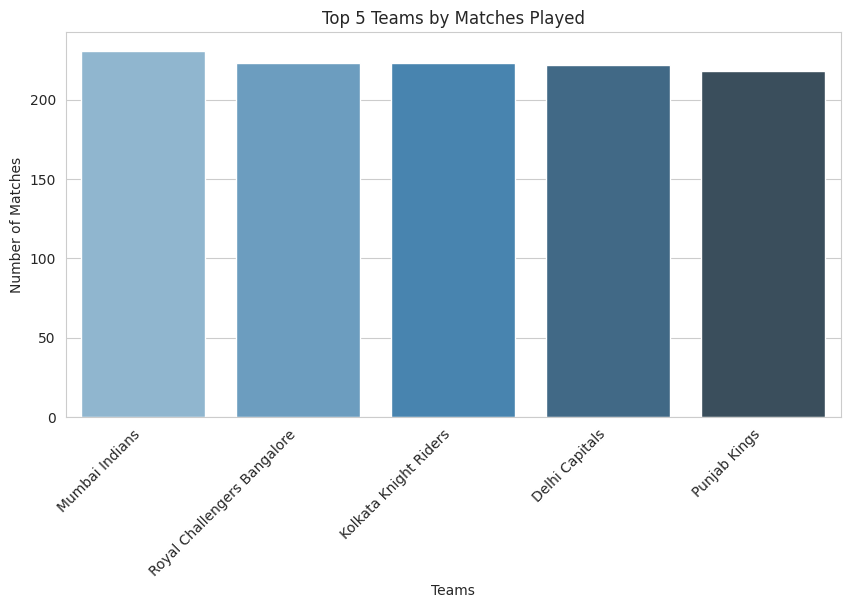

In [23]:
top5_matches = (ipl['Team1'].value_counts() + ipl['Team2'].value_counts()).sort_values(ascending=False).head(5)

sns.barplot(
    x=top5_matches.index,
    y=top5_matches.values,
    hue=top5_matches.index,
    palette='Blues_d',
    legend=False,
)
plt.xticks(rotation=45, ha='right')
plt.title('Top 5 Teams by Matches Played')
plt.ylabel('Number of Matches')
plt.xlabel('Teams')
plt.show()

### Insight:
- MI & RCB have played the most matches

### 2.2 Team Performance Table (Win%, Home/Away Win%)

In [5]:

Teams = ipl['Team1'].unique()
team_df = pd.DataFrame(Teams, columns=['Team Name'])

matches_played = []
home_win_per = []
away_win_per = []
win_per = []

for team in Teams:
    total_matches = len(ipl[(ipl['Team1'] == team) | (ipl['Team2'] == team)])
    matches_played.append(total_matches)

    home_matches = ipl[ipl['Team1'] == team]
    home_wins = home_matches[home_matches['WinningTeam'] == team]
    home_win_per.append(round((len(home_wins) / len(home_matches)) * 100, 2) if len(home_matches) > 0 else 0)

    away_matches = ipl[ipl['Team2'] == team]
    away_wins = away_matches[away_matches['WinningTeam'] == team]
    away_win_per.append(round((len(away_wins) / len(away_matches)) * 100, 2) if len(away_matches) > 0 else 0)

    total_wins = len(ipl[((ipl['Team1'] == team) | (ipl['Team2'] == team)) & (ipl['WinningTeam'] == team)])
    win_per.append(round((total_wins / total_matches) * 100, 2) if total_matches > 0 else 0)

team_df['Matches Played'] = matches_played
team_df['Win%'] = win_per
team_df['Home Win%'] = home_win_per
team_df['Away Win%'] = away_win_per

team_df = team_df.sort_values(by='Win%', ascending=False).reset_index(drop=True)
team_df.head()


,Team Name,Matches Played,Win%,Home Win%,Away Win%
0,Gujarat Titans,16,75.00,57.14,88.89
1,Lucknow Super Giants,15,60.00,87.50,28.57
2,Chennai Super Kings,208,58.17,58.56,57.73
3,Mumbai Indians,231,56.71,58.04,55.46
4,Kolkata Knight Riders,223,51.12,53.33,49.15


### Insight:
- CSK & MI have the highest overall Win% Based On Highest No Of Matches Played

## 3. Player Analysis

### 3.1 Most Player of the Match vs Mumbai Indians

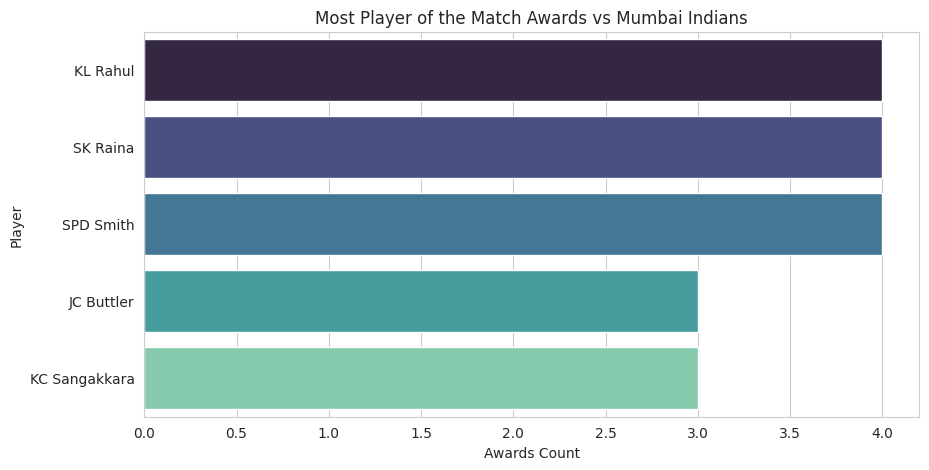

In [24]:

matches_vs_mi = ipl[(ipl['Team1'] == 'Mumbai Indians') | (ipl['Team2'] == 'Mumbai Indians')]
awards = matches_vs_mi[matches_vs_mi['WinningTeam'] != 'Mumbai Indians']['Player_of_Match'].value_counts().head(5)

sns.barplot(x=awards.values, y=awards.index, palette='mako', hue = awards.index, legend = False)
plt.title('Most Player of the Match Awards vs Mumbai Indians')
plt.xlabel('Awards Count')
plt.ylabel('Player')
plt.show()


### 3.2 Player with Most Final Appearances

In [7]:

finals = ipl[ipl['MatchNumber'] == 'Final']
all_players = (finals['Team1Players'].str[1:-1] + finals['Team2Players'].str[1:-1]).str.split(',').sum()
all_players_series = pd.Series(all_players).str.strip().str.strip("'")

all_players_series.value_counts().head(5)


,count
MS Dhoni,10
SK Raina,8
AT Rayudu,7
R Ashwin,7
DJ Bravo,7


## 4. Team vs Team Dashboard

--------- Kolkata Knight Riders vs Chennai Super Kings ---------
--- Win Loss Record ---
WinningTeam
Chennai Super Kings      17
Kolkata Knight Riders     9
Name: count, dtype: int64

--- Win Loss Ratio ---
Kolkata Knight Riders Winning Ratio: 34.62 %
Chennai Super Kings Winning Ratio: 65.38 %

--- Most Player Of The Match ---
Player_of_Match
RA Jadeja    3
Name: count, dtype: int64



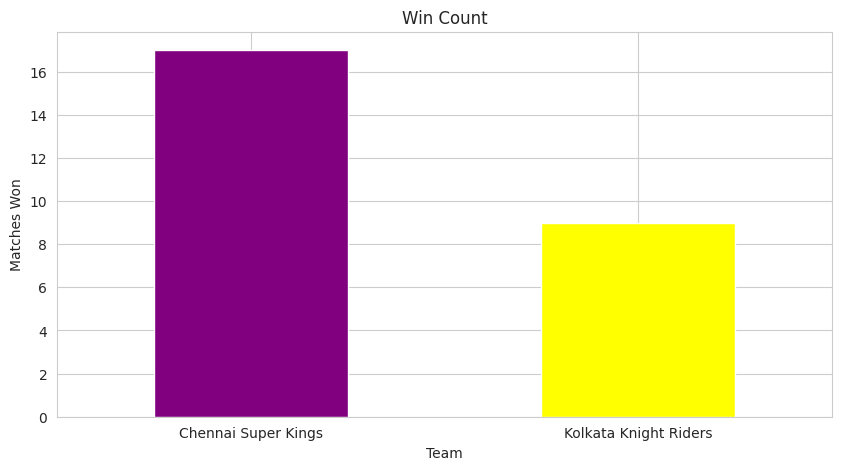

In [8]:

def team1_vs_team2(team1, team2, data):
    print(f"--------- {team1} vs {team2} ---------")

    both_team_rec = data[((data['Team1'] == team1) & (data['Team2'] == team2)) | ((data['Team1'] == team2) & (data['Team2'] == team1))]

    if both_team_rec.empty:
        print("No matches found between the two teams.")
        return

    print('--- Win Loss Record ---')
    winning_rec = both_team_rec['WinningTeam'].value_counts()
    print(winning_rec, end='\n\n')

    print('--- Win Loss Ratio ---')
    team1_win_ratio = (winning_rec.get(team1, 0) / len(both_team_rec)) * 100
    team2_win_ratio = (winning_rec.get(team2, 0) / len(both_team_rec)) * 100

    print(f"{team1} Winning Ratio: {round(team1_win_ratio, 2)} %")
    print(f"{team2} Winning Ratio: {round(team2_win_ratio, 2)} %\n")

    print('--- Most Player Of The Match ---')
    potm_awarded = both_team_rec['Player_of_Match'].value_counts()
    if potm_awarded.empty:
        print("No Player of the Match data available.")
    else:
        top_awardees = potm_awarded[potm_awarded == potm_awarded.max()]
        print(top_awardees,end = '\n\n')

    # Plot Win Count
    winning_rec.plot(kind='bar', title='Win Count', ylabel='Matches Won', xlabel='Team', color=['purple', 'yellow'],rot = 0)

# Example call
team1_vs_team2('Kolkata Knight Riders','Chennai Super Kings',ipl)


## 5. Venue & City Analysis

### 5.1 Venues with Most No-Result Matches

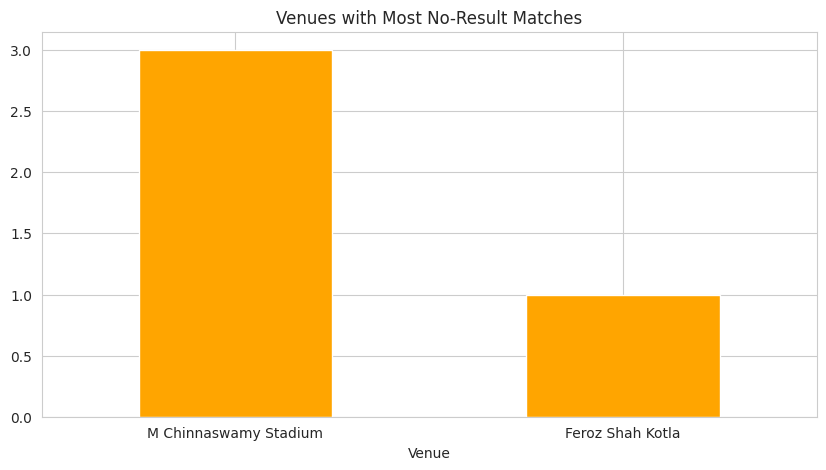

In [39]:
# Using dataset with no result values in 'WinningTeam' Column
ipl_data_no_result[ipl_data_no_result['WinningTeam'].isnull()]['Venue'].value_counts().head().plot(kind='bar',color='orange',rot = 0)
plt.title('Venues with Most No-Result Matches')
plt.show()

### 5.2 Top 7 Cities where KKR Played Most

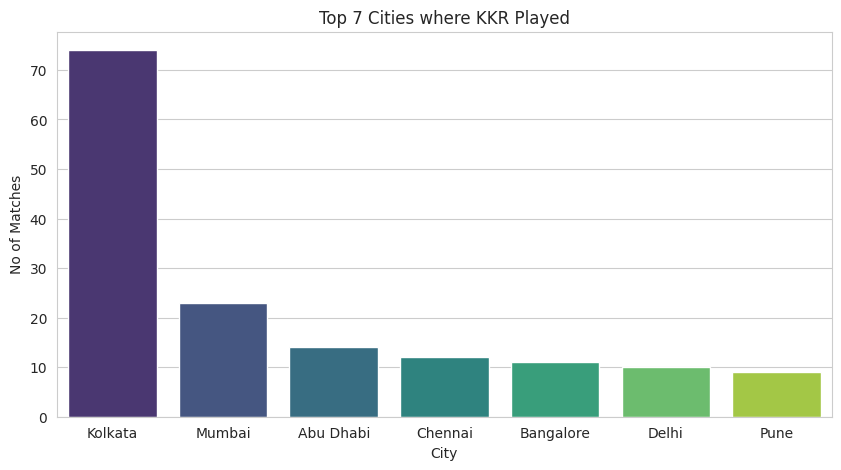

In [25]:

top_7 = ipl[(ipl['Team1'] == 'Kolkata Knight Riders') | (ipl['Team2'] == 'Kolkata Knight Riders')]['City'].value_counts().head(7)
sns.barplot(x=top_7.index, y=top_7.values, palette='viridis', hue =top_7.index, legend = False)
plt.title('Top 7 Cities where KKR Played')
plt.ylabel('No of Matches')
plt.show()


## 6. Miscellaneous Insight

In [12]:

rec_2011 = ipl[ipl['Season'].astype(str).str.contains('2011')]
avg_margin = rec_2011[(rec_2011['Team1'] == 'Mumbai Indians') | (rec_2011['Team2'] == 'Mumbai Indians')]['Margin'].mean()
print(f"Average margin for Mumbai Indians in 2011: {avg_margin}")


Average margin for Mumbai Indians in 2011: 19.25



## 7. Summary of Insights

- MI & CSK are the most consistent teams with top Win% with most matches played.
- MI & RCB have played the most matches.
- M Chinnaswamy Stadium is among the top venues for no-result matches.
- KKR plays most of its matches in Kolkata, Mumbai, and Abu Dhabi.
- MS Dhoni has appeared in the most IPL finals (insight from player data).
- Most Player of the Match vs Mumbai Indians are kl Rahul, Sk Raina and SPD Sumith.
- Average margin for Mumbai Indians in 2011: 19.25.
- Each Team Performance Table With (Win%, Home/Away Win%) In all Ipl (2008-2022).
- Team vs Team Dashboard Function let us know about:
  - Win Count.
  - Win Ratio In Percentage.
  - Players With Most Player Of The Match Awarded.
